In [4]:
import pandas as pd

# Reading Data

* `pd.read_csv` – read data from csv file: [documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
* `pd.read_excel` – read data from excel file: [documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html)

## Exercise 1
Read the data from `data/iris.csv` and assign it to the `iris` variable; preview the variable in notebook 

In [5]:
iris = pd.read_csv("data/iris.csv")
iris

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


## Exercise 2
Read data from `data/iris_modified.csv`.

In [6]:
modified_data = pd.read_csv("data/iris_modified.csv", sep = ";")
modified_data

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


## Exercise 3
Save the `iris` DataFrame to the `iris.xlsx` file (sheet name `iris`). See [to_excel](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_excel.html). (May need to install `openpyxl` package)

In [7]:
iris.to_excel("iris.xlsx", sheet_name = "iris")

## Exercise 4*
Read data from the `miakob` sheet in `data/tablica_a._tablica_trwania_zycia_2019.xlsx`. 

(May need to install `openpyxl` package and specify it as `engine` in order to work)

In [8]:
life_data = pd.read_excel("data/tablica_a._tablica_trwania_zycia_2019.xlsx", engine = "openpyxl")

# DataFrame and Series

The basic types from `pandas` library are [`DataFrame`](https://pandas.pydata.org/docs/reference/frame.html), for representing tabular data, and [`Series`](https://pandas.pydata.org/docs/reference/series.html) for 1-dimensional data (e.g. columns in `DataFrame`)

## Data types
`pandas` uses the same types as `numpy`. 
The following parameters are available:

* `dtypes` for `DataFrame`.
* `dtype` for `Series`.
* Both provide an `astype` method.

In [9]:
iris.dtypes

sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety             str
dtype: object

In [10]:
iris["sepal.length"].dtype

dtype('float64')

## Exercise 5
Create a copy of the `iris` data frame and change the type of `petal.length` to `float32` 

In [11]:
iris_copy = iris.copy()
iris_copy["petal.length"] = iris_copy["petal.length"].astype("float32")
iris_copy.dtypes

sepal.length    float64
sepal.width     float64
petal.length    float32
petal.width     float64
variety             str
dtype: object

# Filtering
You can access column data in `pandas` using two different notations: `df.column_name` or `df["column_name"]`.

To get multiple columns use the following syntax: `df[list_of_column_names]`.

## Exercise 6
Create a data frame with the `Virginica` variety only and calculate its `mean` value and plot a histogram for each numerical column.

array([[<Axes: title={'center': 'sepal.length'}>,
        <Axes: title={'center': 'sepal.width'}>],
       [<Axes: title={'center': 'petal.length'}>,
        <Axes: title={'center': 'petal.width'}>]], dtype=object)

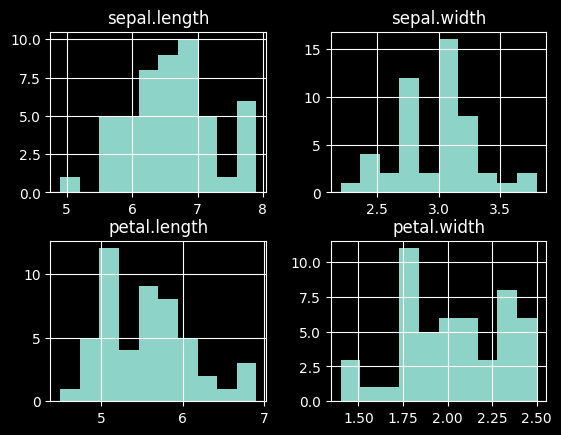

In [12]:
Virginica_data = iris[iris.variety == "Virginica"]
viriginica_mean = Virginica_data.mean(axis = 0, numeric_only=True)
Virginica_data.select_dtypes(include = "number").hist()

## Exercise 7
Save the `iris` data frame to `iris2.xlsx`, with split based on variety. Each type should be in a separate sheet with the sheet name the same as variety.

In [13]:
with pd.ExcelWriter("iris2.xlsx") as writer:
    for variety in iris["variety"].unique():
        df = iris[iris["variety"] == variety]
        df.to_excel(writer, sheet_name = variety, index = False)

# Creating Data Frame
The `pandas` `DataFrame` constructor function is described here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html 




## Exercise 8
Create a `Dataframe` from the following data:
```
data = {
       "sepal.length": [5.006, 5.936, 6.588],
       "sepal.width": [3.428, 2.77 , 2.974],
       "petal.length": [1.462, 4.26 , 5.552],
       "petal.width": [0.246, 1.326, 2.026],
       "variety": ["Setosa", "Versicolor", "Virginica"]
}
```

In [14]:
data = {
    "sepal.length": [5.006, 5.936, 6.588],
    "sepal.width": [3.428, 2.77, 2.974],
    "petal.length": [1.462, 4.26, 5.552],
    "petal.width": [0.246, 1.326, 2.026],
    "variety": ["Setosa", "Versicolor", "Virginica"]
}
my_data_frame = pd.DataFrame(data)

## Exercise 9
Create a `Dataframe` from the following data and set proper column names:

```
[[5.006, 3.428, 1.462, 0.246, 'Setosa'],
[5.936, 2.77, 4.26, 1.326, 'Versicolor'],
[6.588, 2.974, 5.552, 2.026, 'Virginica']]
```

In [15]:
data = [[5.006, 3.428, 1.462, 0.246, 'Setosa'],
[5.936, 2.77, 4.26, 1.326, 'Versicolor'],
[6.588, 2.974, 5.552, 2.026, 'Virginica']]
col_names = iris.columns
data_frame = pd.DataFrame(data, columns = col_names)
data_frame

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.006,3.428,1.462,0.246,Setosa
1,5.936,2.770,4.260,1.326,Versicolor
2,6.588,2.974,5.552,2.026,Virginica


# SQL like operiations
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html


## Exercise 10

Join `df1` and `df2` to produce the same result as `df3`. How would you modify `df4` so that you can join it with `df1` to produce `df3`?

In [16]:
df1 = pd.DataFrame({'sepal.length': {'Setosa': 5.005999999999999,
  'Versicolor': 5.936,
  'Virginica': 6.587999999999998},
 'sepal.width': {'Setosa': 3.428000000000001,
  'Versicolor': 2.7700000000000005,
  'Virginica': 2.9739999999999998}})
df2 = pd.DataFrame({'petal.length': {'Setosa': 1.4620000000000002,
  'Versicolor': 4.26,
  'Virginica': 5.552},
 'petal.width': {'Setosa': 0.2459999999999999,
  'Versicolor': 1.3259999999999998,
  'Virginica': 2.026}})

df3 = pd.DataFrame({'sepal.length': {'Setosa': 5.005999999999999,
  'Versicolor': 5.936,
  'Virginica': 6.587999999999998},
 'sepal.width': {'Setosa': 3.428000000000001,
  'Versicolor': 2.7700000000000005,
  'Virginica': 2.9739999999999998},
 'petal.length': {'Setosa': 1.4620000000000002,
  'Versicolor': 4.26,
  'Virginica': 5.552},
 'petal.width': {'Setosa': 0.2459999999999999,
  'Versicolor': 1.3259999999999998,
  'Virginica': 2.026}})
df4 = pd.DataFrame({'petal.length': {0: 1.4620000000000002, 1: 4.26, 2: 5.552},
 'petal.width': {0: 0.2459999999999999, 1: 1.3259999999999998, 2: 2.026}})

In [17]:
ans = df1.join(df2, how = 'left')
ans

,sepal.length,sepal.width,petal.length,petal.width
Setosa,5.006,3.428,1.462,0.246
Versicolor,5.936,2.770,4.260,1.326
Virginica,6.588,2.974,5.552,2.026


## Exercise 11*
How is `df3` from the previous exercise produced from the `iris` `DataFrame`?

In [18]:
ans = iris.groupby("variety").mean().rename_axis(None, axis=0)
ans

,sepal.length,sepal.width,petal.length,petal.width
Setosa,5.006,3.428,1.462,0.246
Versicolor,5.936,2.770,4.260,1.326
Virginica,6.588,2.974,5.552,2.026


## Exercise 12
Join the `dd1` and `dd2` `DataFrame`s using `variety` column.  

In [19]:
dd1 = pd.DataFrame({'sepal.length': {0: 5.005999999999999, 1: 5.936, 2: 6.587999999999998},
 'sepal.width': {0: 3.428000000000001,
  1: 2.7700000000000005,
  2: 2.9739999999999998},
 'variety': {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}})

dd2 = pd.DataFrame({'petal.length': {0: 1.4620000000000002, 1: 4.26, 2: 5.552},
 'petal.width': {0: 0.2459999999999999, 1: 1.3259999999999998, 2: 2.026},
 'variety': {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}})

ans = dd1.join(dd2.set_index("variety"), on="variety")
ans

,sepal.length,sepal.width,variety,petal.length,petal.width
0,5.006,3.428,Setosa,1.462,0.246
1,5.936,2.770,Versicolor,4.260,1.326
2,6.588,2.974,Virginica,5.552,2.026


# Time data aggregation

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html


## Exercise 13*
`data/book_extract.csv` file consists of records regarding financial performance of dealers. Prepare a report which explicates financial performance of dealers eligible for a payable bonus based on net result (`income-(clawback+opex)`) for each calendar month, given that opex/income ratio does not exceed 15%.

Report should have tabular form, rows indicating bonus basis for each month with at least one eligible dealer, columns indicating all dealers.

In [20]:
data = pd.read_csv("data/book_extract.csv")
data['month'] = pd.to_datetime(data['date']).dt.month
data.set_index(data["Unnamed: 0"], inplace=True)
data = data.rename_axis(None, axis=0)
data

,Unnamed: 0,name,date,operation type,amount,month
0,0,Marie Pugh,2020-05-08,income,107.513913,5
1,1,Havin Cope,2020-04-19,clawback,147.318495,4
2,2,Havin Cope,2020-01-07,opex,8.189630,1
3,3,Havin Cope,2020-03-14,income,349.687260,3
4,4,Marie Pugh,2020-03-16,opex,76.655636,3
...,...,...,...,...,...,...
995,995,Havin Cope,2020-03-04,clawback,895.713291,3
996,996,Frazer Bone,2020-09-13,clawback,31.235687,9
997,997,Havin Cope,2020-06-07,income,437.871498,6
998,998,Havin Cope,2020-02-17,opex,8.111265,2


In [21]:
data = pd.pivot_table(data = data, index = ["name", "month"], columns = "operation type", values = "amount", aggfunc="sum")

In [22]:
data["net_income"] = data["income"] - data["clawback"] - data["opex"]
data[data["opex"]/data["income"]>= 0.15]["net_income"]

name           month
Frazer Bone    2        -603.892482
               3        1042.092249
               4        1455.128996
               5        2117.586939
               6        3353.442800
               7        1576.947509
               8         570.515892
               9        -251.940224
Grady Kearney  2         331.371190
               5        -596.176242
               6        1232.693900
               7        2406.337321
               8        1091.486292
Havin Cope     1       -1851.353697
               2         688.549628
               4       -1329.795612
               5         528.735703
               6         736.367854
               7         482.666801
               8       -1289.095236
Iyla Tate      5         394.084228
               6        1003.020194
               7         508.158287
               8         157.720557
               9        1224.089263
               10       -307.926819
Marie Pugh     2       -1072.738224
       